In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU is connected")

CUDA available: True
CUDA version: 12.8
GPU: Tesla T4


In [ ]:
!pip install -q \
transformers==4.51.3 \
trl==0.17.0 \
peft==0.15.2 \
accelerate==1.6.0 \
bitsandbytes==0.46.0 \
datasets==3.5.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.0/348.0 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.1/411.1 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 108.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.12.0 which is incompatible.
gradio 

In [ ]:

import transformers, trl, peft, accelerate, bitsandbytes

print(transformers.__version__)
print(trl.__version__)
print(peft.__version__)
print(accelerate.__version__)
print(bitsandbytes.__version__)

4.51.3
0.17.0
0.15.2
1.6.0
0.46.0


In [ ]:
from huggingface_hub import login
from google.colab import userdata

login(userdata.get("HF_TOKEN"), add_to_git_credential=True)

In [ ]:
import torch

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)

from peft import (
    LoraConfig,
    get_peft_model,
)

from trl import (
    SFTTrainer,
    SFTConfig,
)

In [ ]:
# Hyperparameters

BASE_MODEL = "Qwen/Qwen2.5-3B-Instruct"

MAX_SEQUENCE_LENGTH = 1024

LORA_R = 32
LORA_ALPHA = 64
LORA_DROPOUT = 0.1

TARGET_MODULES = [
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
]

OUTPUT_DIR = "ai-learning-coach-qwen-lora"
# --- Hugging Face Hub target repo ---
from datetime import datetime
# --- Hugging Face Hub target repo ---
HF_USER = "GayatriRajagopalan"  # <-- replace with your Hugging Face username
RUN_NAME = f"{datetime.now():%Y-%m-%d_%H.%M}"
HUB_MODEL_NAME = f"{HF_USER}/ai-learning-coach-qwen-lora-{RUN_NAME}"

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving sft_dataset.jsonl to sft_dataset.jsonl


In [ ]:
# Load JSONL
dataset = load_dataset(
    "json",
    data_files="sft_dataset.jsonl",
    split="train"
)

# First split: 80% train, 20% temp
split = dataset.train_test_split(
    test_size=0.2,
    seed=42,
)

train_dataset = split["train"]
temp_dataset = split["test"]

# Second split: split temp equally into val and test
split = temp_dataset.train_test_split(
    test_size=0.5,
    seed=42,
)

val_dataset = split["train"]
test_dataset = split["test"]

print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Generating train split: 0 examples [00:00, ? examples/s]

Train: 492
Validation: 62
Test: 62


In [ ]:
# Load the Qwen tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def to_prompt_completion(example):
    return {
        "prompt": [example["messages"][0]],
        "completion": [example["messages"][1]],
    }

train_dataset = train_dataset.map(
    to_prompt_completion,
    remove_columns=["messages"],
)

val_dataset = val_dataset.map(
    to_prompt_completion,
    remove_columns=["messages"],
)

test_dataset = test_dataset.map(
    to_prompt_completion,
    remove_columns=["messages"],
)

Map:   0%|          | 0/492 [00:00<?, ? examples/s]

Map:   0%|          | 0/62 [00:00<?, ? examples/s]

Map:   0%|          | 0/62 [00:00<?, ? examples/s]

In [ ]:
train_dataset[0]

{'prompt': [{'content': 'What is the difference between a base model and a chat model?',
   'role': 'user'}],
 'completion': [{'content': 'What is it?  \nA base model is a type of AI model that has been trained on a large amount of text data. It learns patterns in language and can generate coherent text, but it does not have a specific focus or conversational structure. A chat model, on the other hand, is built on top of a base model and is specifically fine-tuned for conversations. It understands context, maintains dialogue flow, and can provide responses that feel natural in a chat setting.\n\nWhy do we need it?  \nBase models serve as the foundation for various natural language tasks. They provide the ability to generate text and understand language. However, for applications like chatbots or virtual assistants, we need chat models. These chat models are tailored to handle user interactions, providing relevant responses while considering the conversational context. This focus enhanc

In [ ]:
# Load Qwen in 4-bit
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quantization_config,
    torch_dtype=torch.float16,
)

model.config.use_cache = False

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
# Prepare the 4-bit model and add LoRA

from peft import prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=TARGET_MODULES,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)




In [ ]:
for param in model.parameters():
    if param.requires_grad:
        param.data = param.data.float()

In [ ]:
bf16_params = [
    name
    for name, param in model.named_parameters()
    if param.requires_grad and param.dtype == torch.bfloat16
]

print(len(bf16_params))

0


In [ ]:
model.print_trainable_parameters()

trainable params: 14,745,600 || all params: 3,100,684,288 || trainable%: 0.4756


In [ ]:
# create sft config
training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    logging_steps=5,
    eval_strategy="steps",
    eval_steps=10,
    save_strategy="steps",
    save_steps=10,
    max_length=MAX_SEQUENCE_LENGTH,
    fp16=True,
    bf16=False,
    report_to="none",
    # --- push each checkpoint to the Hugging Face Hub as it saves ---
    push_to_hub=True,
    hub_model_id=HUB_MODEL_NAME,
    hub_strategy="every_save",
    # --- automatically track + reload the checkpoint with the lowest eval loss ---
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

)

In [ ]:
# create SFTTrainer

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

Converting train dataset to ChatML:   0%|          | 0/492 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/492 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/492 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/492 [00:00<?, ? examples/s]

Converting eval dataset to ChatML:   0%|          | 0/62 [00:00<?, ? examples/s]

Applying chat template to eval dataset:   0%|          | 0/62 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/62 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/62 [00:00<?, ? examples/s]

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [ ]:
print(training_args.fp16)
print(training_args.bf16)

print(model.dtype)

import torch
print(torch.cuda.get_device_name(0))

True
False
torch.float32
Tesla T4


In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
10,1.115100,1.068494
20,1.037200,1.015652
30,0.997200,0.998731
40,0.932600,0.992380
50,0.966400,0.987423
60,0.962000,0.984499
70,0.944100,0.983929
80,0.900200,0.982726
90,0.936800,0.982319


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

TrainOutput(global_step=90, training_loss=1.0123944388495552, metrics={'train_runtime': 1579.102, 'train_samples_per_second': 0.935, 'train_steps_per_second': 0.057, 'total_flos': 1.1936074389504e+16, 'train_loss': 1.0123944388495552})

In [ ]:
# --- Which checkpoint had the lowest eval loss? ---
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best eval loss:", trainer.state.best_metric)

Best checkpoint: ai-learning-coach-qwen-lora/checkpoint-90
Best eval loss: 0.9823185205459595


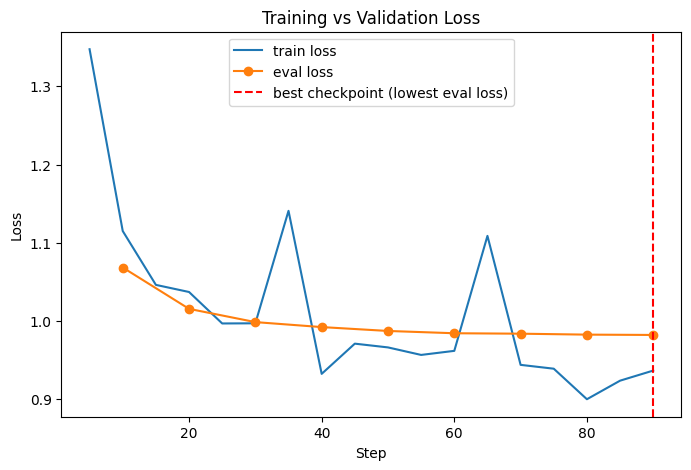

In [ ]:
# --- Plot train vs. eval loss across checkpoints ---
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)

train_loss = history[history["loss"].notna()][["step", "loss"]]
eval_loss = history[history["eval_loss"].notna()][["step", "eval_loss"]]

best_step = eval_loss.loc[eval_loss["eval_loss"].idxmin(), "step"]

plt.figure(figsize=(8, 5))
plt.plot(train_loss["step"], train_loss["loss"], label="train loss")
plt.plot(eval_loss["step"], eval_loss["eval_loss"], label="eval loss", marker="o")
plt.axvline(x=best_step, color="red", linestyle="--", label="best checkpoint (lowest eval loss)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...en-lora/training_args.bin: 100%|##########| 6.10kB / 6.10kB            

  ...adapter_model.safetensors:  41%|####      | 24.0MB / 59.0MB            

  ...-qwen-lora/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

('ai-learning-coach-qwen-lora/tokenizer_config.json',
 'ai-learning-coach-qwen-lora/special_tokens_map.json',
 'ai-learning-coach-qwen-lora/vocab.json',
 'ai-learning-coach-qwen-lora/merges.txt',
 'ai-learning-coach-qwen-lora/added_tokens.json',
 'ai-learning-coach-qwen-lora/tokenizer.json')

In [ ]:
from huggingface_hub import HfApi

api = HfApi()
api.upload_folder(
    folder_path=OUTPUT_DIR,
    repo_id=HUB_MODEL_NAME,
    commit_message="Push best checkpoint (lowest eval loss)",
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:  14%|#3        | 7.97MB / 59.0MB            

  ...adapter_model.safetensors:  13%|#3        | 7.90MB / 59.0MB            

  ...ckpoint-50/tokenizer.json:  70%|######9   | 7.99MB / 11.4MB            

...

  ...a/checkpoint-50/scaler.pt: 100%|##########| 1.38kB / 1.38kB            

  ...adapter_model.safetensors:  13%|#3        | 7.94MB / 59.0MB            

  ...oint-60/training_args.bin: 100%|##########| 6.10kB / 6.10kB            

  ...ckpoint-60/tokenizer.json:  70%|######9   | 7.99MB / 11.4MB            

CommitInfo(commit_url='https://huggingface.co/GayatriRajagopalan/ai-learning-coach-qwen-lora-2026-07-20_01.42/commit/d169d99fa0be48d7efc519ca81f80fb79db00e0f', commit_message='Push best checkpoint (lowest eval loss)', commit_description='', oid='d169d99fa0be48d7efc519ca81f80fb79db00e0f', pr_url=None, repo_url=RepoUrl('https://huggingface.co/GayatriRajagopalan/ai-learning-coach-qwen-lora-2026-07-20_01.42', endpoint='https://huggingface.co', repo_type='model', repo_id='GayatriRajagopalan/ai-learning-coach-qwen-lora-2026-07-20_01.42'), pr_revision=None, pr_num=None)

In [ ]:
from peft import AutoPeftModelForCausalLM
from transformers import AutoTokenizer

model = AutoPeftModelForCausalLM.from_pretrained(
    OUTPUT_DIR,
    torch_dtype=torch.float16,
    device_map="auto",
)

tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
def ask(question):
    messages = [
        {
            "role": "user",
            "content": question,
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        text,
        return_tensors="pt",
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False,
    )

    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    response = tokenizer.decode(
        new_tokens,
        skip_special_tokens=True,
    )

    print(response)

In [ ]:
ask("Explain Random Forest.")

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:653: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


What is it?  
Random Forest is an ensemble learning method used for both classification and regression tasks. It works by creating multiple decision trees during the training phase and then combining their predictions to make a final decision. Each tree in the forest is trained on a random subset of the data and features, which helps reduce overfitting.

Why do we need it?  
We need Random Forest because it can handle large datasets with many variables effectively. Traditional decision trees can be prone to overfitting, especially when dealing with noisy or complex data. By averaging the predictions from multiple trees, Random Forest reduces this risk and improves model accuracy.

Real-world analogy  
Think of Random Forest like a group of experts making decisions about a project. Instead of relying on just one expert's opinion, they gather input from several different individuals. Each expert may have unique insights, but by considering multiple perspectives, they can make a more info

In [ ]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [ ]:
!pip install -q "gradio==5.31.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.1/323.1 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.8/444.8 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
python-fasthtml 0.14.6 requires starlette>=1.0.1, but you have starlette 0.52.1 which is incompatible.
google-adk 2.4.0 requires pydantic<3,>=2.12, but you have pydantic 2.11.10 which is incompatible.
google-adk 2.4.0 requires starlette<2,>=1.0.1, but you have starlette

In [ ]:
import gradio
print(gradio.__version__)

5.31.0


In [ ]:
# =========================================================
#   AI Learning Coach — Gradio Demo
# =========================================================


import torch
import threading
import gradio as gr
from peft import AutoPeftModelForCausalLM, PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, TextIteratorStreamer

# ---------------------------------------------------------
# 1. Load your fine-tuned model from the Hugging Face Hub
#    Replace with the exact repo id printed when training
#    finished, e.g. "GayatriRajagopalan/ai-learning-coach-qwen-lora-2025-07-17_10.32"
# ---------------------------------------------------------
HUB_REPO_ID = "GayatriRajagopalan/ai-learning-coach-qwen-lora-2026-07-20_01.42"

BASE_MODEL = "Qwen/Qwen2.5-3B-Instruct"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map={"": 0},
)

model = PeftModel.from_pretrained(
    base_model,
    HUB_REPO_ID,
    subfolder="checkpoint-40",
    revision="d169d99fa0be48d7efc519ca81f80fb79db00e0f",
)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(
    HUB_REPO_ID,
    subfolder="checkpoint-40",
    revision="d169d99fa0be48d7efc519ca81f80fb79db00e0f",
)

print("Model loaded")

# ---------------------------------------------------------
# 2. Streaming generation function
# ---------------------------------------------------------
def coach_reply(message, history):
    # Rebuild the conversation in chat-template format
    messages = []
    for turn in history:
        role = turn["role"]
        content = turn["content"]
        messages.append({"role": role, "content": content})
    messages.append({"role": "user", "content": message})

    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)

    streamer = TextIteratorStreamer(
        tokenizer,
        skip_prompt=True,
        skip_special_tokens=True,
    )

    generation_kwargs = dict(
        **inputs,
        streamer=streamer,
        max_new_tokens=512,
        do_sample=False,
        #temperature=0.2,
        #top_p=0.9,
        #repetition_penalty=1.1,
    )

    thread = threading.Thread(target=model.generate, kwargs=generation_kwargs)
    thread.start()

    partial_response = ""
    for new_text in streamer:
        partial_response += new_text
        yield partial_response

# ---------------------------------------------------------
# 3. Gradio interface
# ---------------------------------------------------------
theme = gr.themes.Soft(
    primary_hue="indigo",
    secondary_hue="sky",
    font=[gr.themes.GoogleFont("Inter"), "sans-serif"],
)

example_questions = [
    "Explain Random Forest like I'm new to machine learning.",
    "What's the difference between supervised and unsupervised learning?",
    "Walk me through how gradient descent works.",
    "When should I use precision vs. recall as a metric?",
    "What is overfitting and how do I prevent it?",
]

demo = gr.ChatInterface(
    fn=coach_reply,
    type="messages",
    title="AI Learning Coach",
    description=(
        "A fine-tuned Qwen2.5-3B model trained to explain machine learning "
        "and AI concepts clearly and patiently. Ask it anything you're "
        "learning about!"
    ),
    examples=example_questions,
    theme=theme,
    chatbot=gr.Chatbot(height=480, label="AI Learning Coach", avatar_images=(None, "🎓"), type="messages"),
    textbox=gr.Textbox(placeholder="Ask a question, e.g. 'Explain Random Forest'", scale=7),
    submit_btn="Ask",
)

demo.launch(share=True, debug=True)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

checkpoint-40/tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

checkpoint-40/tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

Model loaded
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4a8ca5dbde9bfb0e53.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
